<a href="https://colab.research.google.com/github/maheshisewwandisamaraweera/image-authentication-project/blob/maheshi/notebooks/Model_h5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNet

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

In [3]:
data_path = "/content/drive/MyDrive/image-authentication-project/data"

model_path = "/content/drive/MyDrive/image-authentication-project/models/model.h5"

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

print(os.listdir('/content/drive/MyDrive/image-authentication-project'))

['README.md', '.gitignore', 'train.py', 'src', 'notebooks', '.git', 'models', 'data']


In [6]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32


datagen = ImageDataGenerator(
    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


classes = [
    "actual",
    "edited",
    "ai_generated"
]


train_generator = datagen.flow_from_directory(

    data_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    classes=classes,

    class_mode="categorical",

    subset="training",

    shuffle=True

)



validation_generator = datagen.flow_from_directory(

    data_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    classes=classes,

    class_mode="categorical",

    subset="validation",

    shuffle=False

)


print(train_generator.class_indices)

Found 456 images belonging to 3 classes.
Found 111 images belonging to 3 classes.
{'actual': 0, 'edited': 1, 'ai_generated': 2}


In [7]:
base_model = MobileNet(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)


# Freeze pretrained layers

base_model.trainable = False



x = base_model.output


x = GlobalAveragePooling2D()(x)


x = Dropout(0.3)(x)



output = Dense(

    3,

    activation="softmax"

)(x)



model = Model(

    inputs=base_model.input,

    outputs=output

)



model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)



model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,231,939 (12.33 MB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [9]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20

)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 157s 11s/step - accuracy: 0.3421 - loss: 1.5732 - val_accuracy: 0.3604 - val_loss: 1.2986
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.3509 - loss: 1.3898 - val_accuracy: 0.4414 - val_loss: 1.2529
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3311 - loss: 1.4464 - val_accuracy: 0.4144 - val_loss: 1.2422
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.4013 - loss: 1.2995 - val_accuracy: 0.4775 - val_loss: 1.1312
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.3377 - loss: 1.3794 - val_accuracy: 0.4775 - val_loss: 1.1389
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3750 - loss: 1.2928 - val_accuracy: 0.4505 - val_loss: 1.1167
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4649 - loss: 1.1305 - val_accuracy: 0.4595 - val_loss: 1.1007
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.4232 - loss: 1.2469 - val_accuracy: 0.4865 - val_los

In [10]:
model.save(model_path)

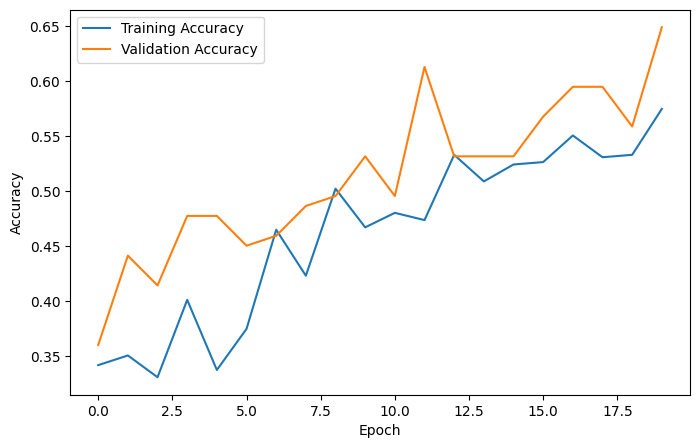

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [12]:
loss, accuracy = model.evaluate(
    validation_generator
)

print(
    "Validation Accuracy:",
    accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5856 - loss: 0.8097
Validation Accuracy: 0.5855855941772461


In [13]:
model.save(model_path)

print("Model saved successfully")

Model saved successfully
